<a href="https://colab.research.google.com/github/kurexi/ml-labs/blob/main/Lab8_Excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Exploring the latent space of VAE

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm import tqdm
from itertools import chain

import numpy as np

class Encoder(nn.Module):
    '''
    simple encoder with a single hidden dense layer (ReLU activation)
    and linear projections to the diag-Gauss parameters
    '''
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Encoder, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)

        self.fc_mean = nn.Linear(hidden_dim, output_dim)
        self.fc_logvar = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out = F.relu(self.fc1(x))
        mean = self.fc_mean(out)
        logvar = self.fc_logvar(out)

        return mean, logvar

class Decoder(nn.Module):
    '''
    simple decoder: single dense hidden layer (ReLU activation) followed by
    output layer with a sigmoid to squish values
    '''
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out = F.relu(self.fc1(x))
        return F.sigmoid(self.fc2(out))

image_dim = 784
embedding_dim = 2
enc_hidden_units = 512
dec_hidden_units = 512

dec = Decoder(embedding_dim, dec_hidden_units, image_dim)
dec.load_state_dict(torch.load('decoder.weights'))


<All keys matched successfully>

In [49]:
x = torch.linspace(-4, 4, 21)
y = torch.linspace(4, -4, 21)

grid_x, grid_y = torch.meshgrid(x, y, indexing='xy')
z = torch.stack([grid_x, grid_y], dim=-1)

In [50]:
dec.eval()
outputs = dec(z)

(np.float64(-0.5), np.float64(587.5), np.float64(587.5), np.float64(-0.5))

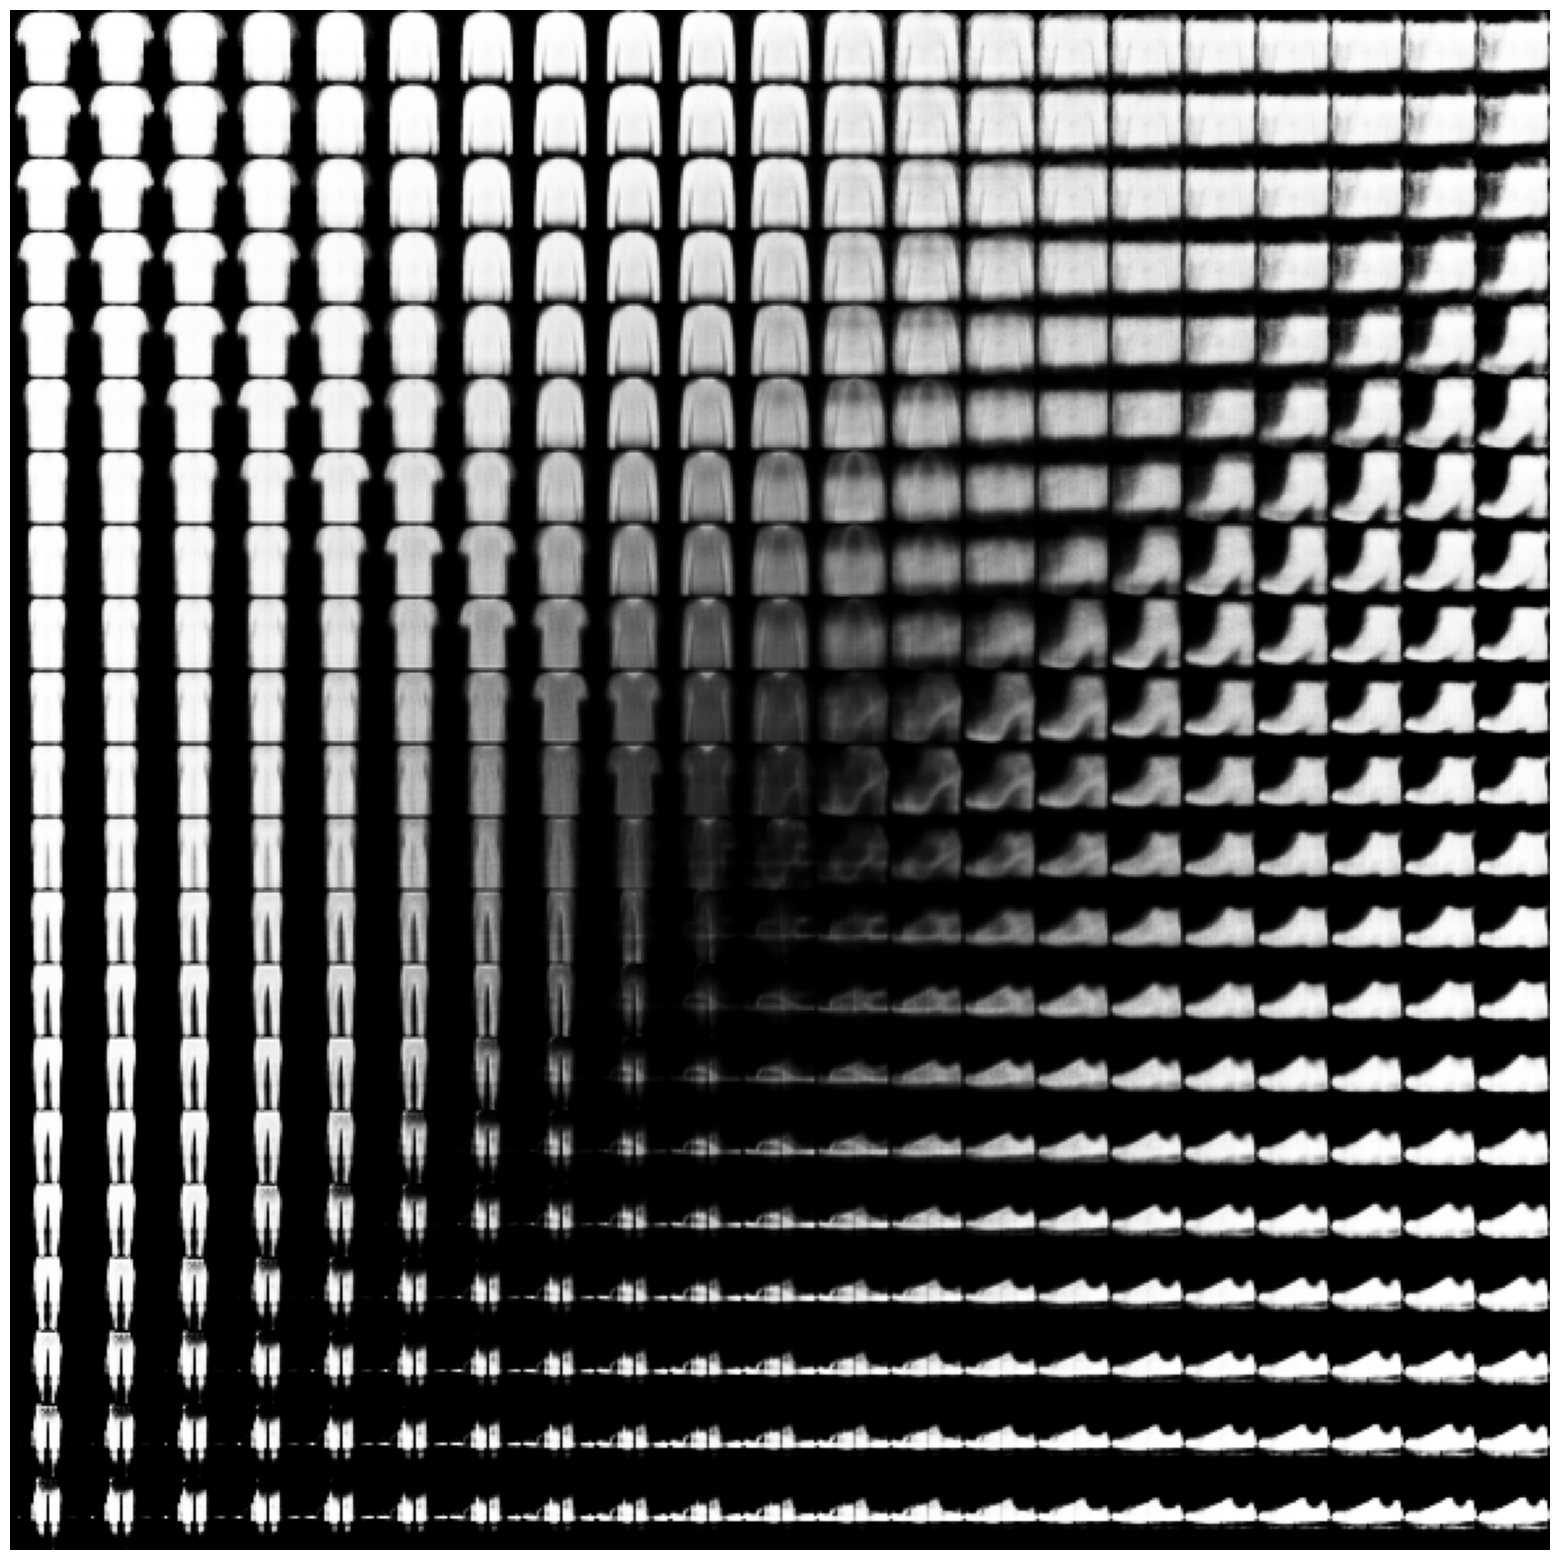

In [51]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20,20))
plt.imshow(outputs.reshape(21, 21, 28, 28).permute(0, 2, 1, 3).reshape(588, 588).detach().numpy(), cmap=plt.get_cmap('gray'))
plt.axis('off')

# 2 Exploring the code space of standard auto-encoder

In [54]:
import torch
import torchvision
import torchvision.transforms as transforms

batch_size = 256

# dataset construction
transform = transforms.Compose([
    transforms.ToTensor(), # convert to tensor
    transforms.Lambda(lambda x: x.view(image_dim)) # flatten into vector
    ])

train_set = torchvision.datasets.FashionMNIST(
    root='./data/FashionMNIST'
    ,train=True
    ,download=True
    ,transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 279kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.11MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.7MB/s]


In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    '''
    simple encoder with no hidden dense layer
    '''
    def __init__(self, input_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.fc = nn.Linear(input_dim, hidden_dim)

    def forward(self, x):
        return self.fc(x)

class Decoder(nn.Module):
    '''
    simple decoder: single dense hidden layer followed by
    output layer with a sigmoid to squish values
    '''
    def __init__(self, input_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        out = self.fc(x)
        return F.sigmoid(out)

In [ ]:
import matplotlib.gridspec as gridspec
import os
import torch.optim as optim
import numpy as np

from tqdm.autonotebook import tqdm
from itertools import chain

enc_dim = 2
image_dim = 784  # [flattened]
nEpoch = 10

# construct the encoder, decoder and optimiser
enc = Encoder(image_dim, enc_dim)
dec = Decoder(enc_dim, image_dim)
optimizer = optim.Adam(chain(enc.parameters(), dec.parameters()), lr=1e-3)

# training loop
for epoch in range(nEpoch):

    losses = []
    trainloader = tqdm(train_loader)

    for i, data in enumerate(trainloader, 0):
        inputs, _ = data
        optimizer.zero_grad()

        z = enc(inputs)
        outputs = dec(z)

        loss = F.binary_cross_entropy(outputs, inputs, reduction='sum') / inputs.shape[0]
        loss.backward()
        optimizer.step()

        # keep track of the loss and update the stats
        losses.append(loss.item())
        trainloader.set_postfix(loss=np.mean(losses), epoch=epoch)

(np.float64(-0.5), np.float64(587.5), np.float64(587.5), np.float64(-0.5))

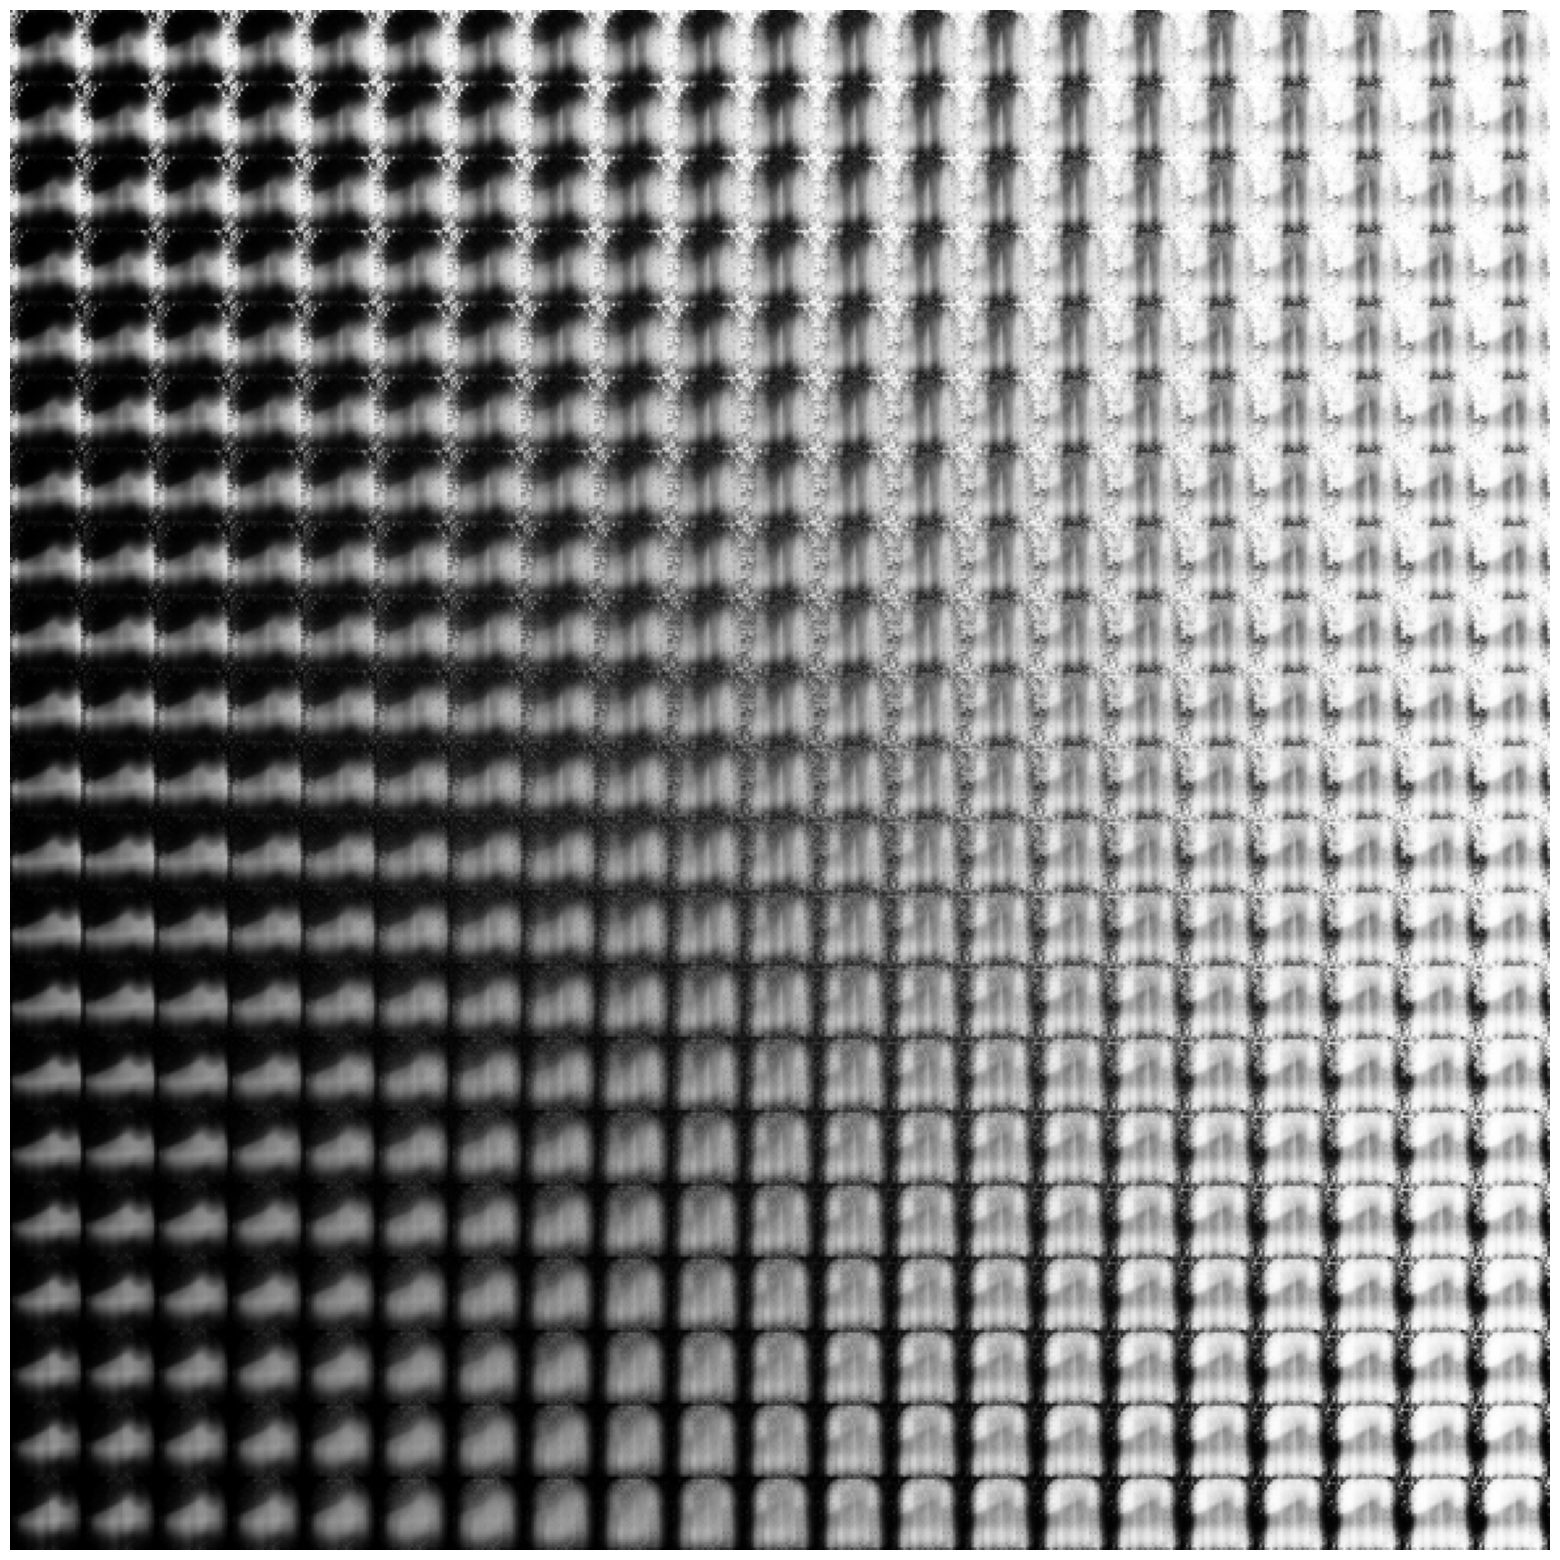

In [69]:
x = torch.linspace(-4, 4, 21)
y = torch.linspace(4, -4, 21)

grid_x, grid_y = torch.meshgrid(x, y, indexing='xy')
z = torch.stack([grid_x, grid_y], dim=-1)

dec.eval()
outputs = dec(z)

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20,20))
plt.imshow(outputs.reshape(21, 21, 28, 28).permute(0, 2, 1, 3).reshape(588, 588).detach().numpy(), cmap=plt.get_cmap('gray'))
plt.axis('off')